In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
wc = 0.8
ac = 0.1
n = 4
k = 0.5

cond = ((n-1)**2 / (4*n))*wc- ac
print(cond) # positive if hysteresis in k

C_lower = 1/(1+wc/ac) # lower limit where k(c) blows up



0.35


In [18]:
if cond > 0:
    C_plus = ((n-1)*wc + 2*n*ac + np.sqrt((n-1)**2 * wc**2 - 4*n*wc*ac))/(2*n*(wc+ac))
    C_minus = ((n-1)*wc + 2*n*ac - np.sqrt((n-1)**2 * wc**2 - 4*n*wc*ac))/(2*n*(wc+ac))
else:
    C_plus = 1
    C_minus = C_lower

print(C_minus, C_plus)

0.15047207654837882 0.7384168123405102


In [27]:
def hyst(C,wc,ac,n):
    return ((C**(n+1) - C**n)/(-(1 +wc/ac)*C +1))**(1/n)

In [28]:
np.array([1,2,3.5])**2

array([ 1.  ,  4.  , 12.25])

In [164]:
ep   = 0.0001
ep2  = 0.0002 # decrease to increase high end of k
dx   = 0.0001
dxx1 = 0.00001
dxx2 = 0.000000001 # make small to get close to k = 0
cverylow = np.arange(C_lower + ep2, C_lower + 15*ep2,dxx1)
clow = np.arange(cverylow[-1], C_minus,dx)
cmid = np.arange(C_minus,C_plus,dx)
chigh = np.arange(C_plus, 1.0-ep,dx)
cveryhigh = np.arange(chigh[-1],1.0,dxx2)

kverylow = hyst(cverylow,wc,ac,n)
klow = hyst(clow,wc,ac,n)
kmid = hyst(cmid,wc,ac,n)
khigh = hyst(chigh,wc,ac,n)
kveryhigh = hyst(cveryhigh,wc,ac,n)

In [165]:
chigh[-1]

np.float64(0.9998168123404814)

In [166]:
cveryhigh[0]

np.float64(0.9998168123404814)

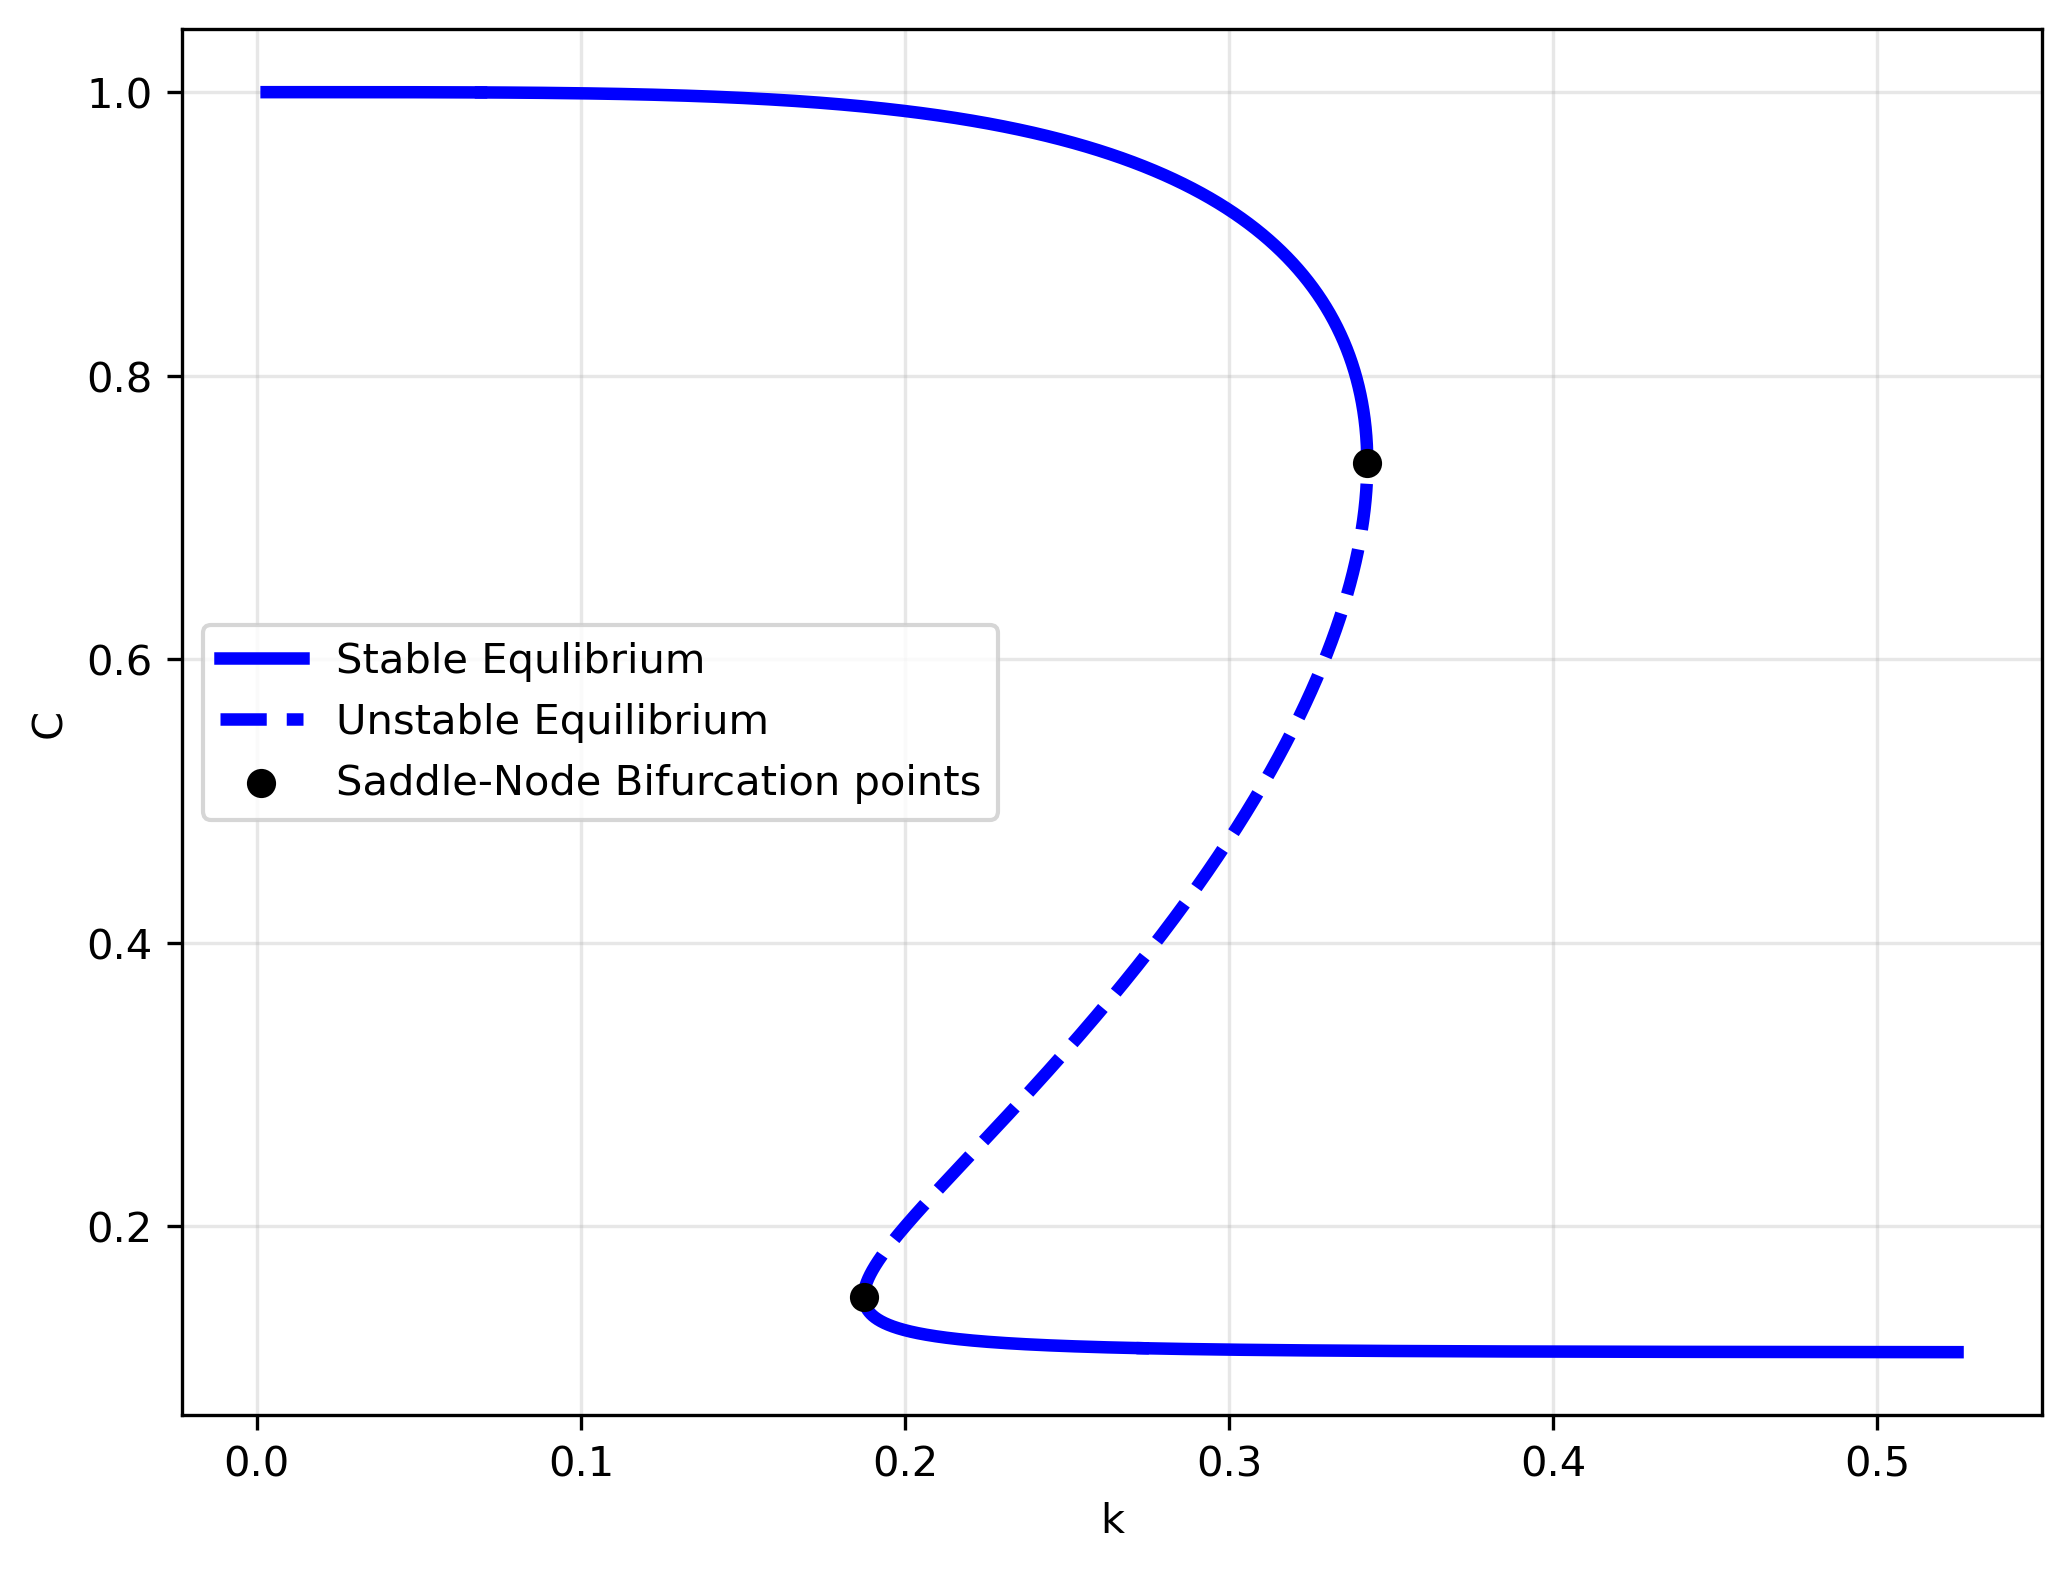

In [167]:
fig, ax = plt.subplots(figsize=(8, 6),dpi = 300)
ax.plot(klow, clow,lw = 3,c = "b", label = "Stable Equlibrium")
ax.plot(kmid, cmid,lw = 3, c = "b",linestyle = "--", label = "Unstable Equilibrium")
ax.plot(khigh, chigh,lw = 3,c = "b")
ax.plot(kveryhigh, cveryhigh,lw = 3,c = "b")
ax.plot(kverylow, cverylow,lw = 3,c = "b")
ax.set_xlabel("k")
ax.set_ylabel("C")
ax.scatter(hyst(np.array([C_plus,C_minus]),wc,ac,n),np.array([C_plus,C_minus]),c = "black",zorder = 2,label = "Saddle-Node Bifurcation points")
ax.grid(alpha = 0.3)
ax.legend()
plt.show()
